  CAR PRICE PREDICTION — ML PIPELINE

[1] Dataset loaded: 301 rows × 9 columns
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

[2] Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year  

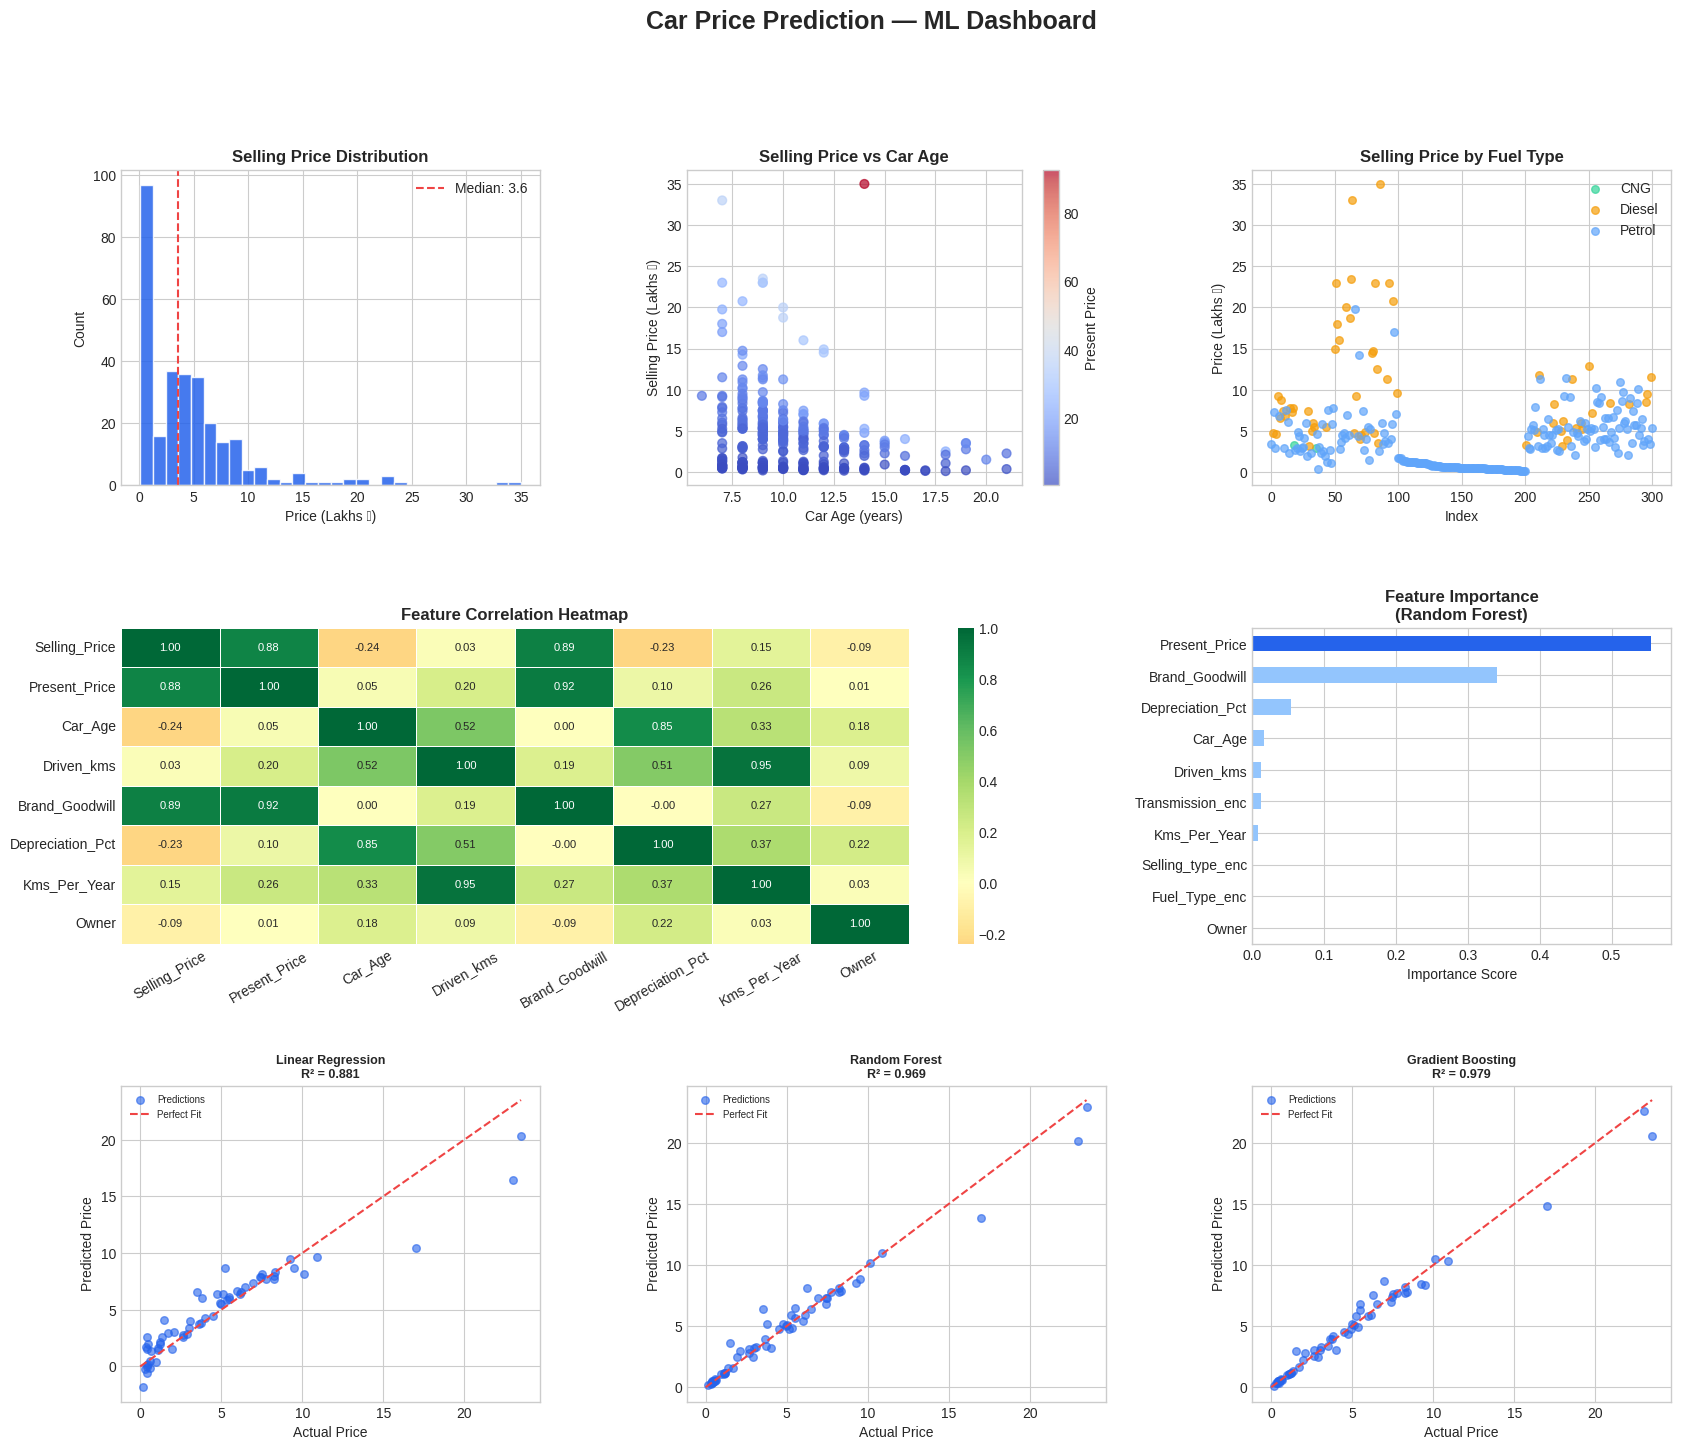

In [2]:
"""
Car Price Prediction using Machine Learning
============================================
Predicts used car selling prices using regression models.
Dataset features: Car Name, Year, Present Price, Driven KMs,
                  Fuel Type, Selling Type, Transmission, Owner
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
print("=" * 55)
print("  CAR PRICE PREDICTION — ML PIPELINE")
print("=" * 55)

df = pd.read_csv("car_data.csv")
print(f"\n[1] Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head())

# ─────────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────
print("\n[2] Data Overview")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nBasic Stats:\n", df.describe())

# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────
print("\n[3] Feature Engineering")

# Car age is more meaningful than year
current_year = 2024
df['Car_Age'] = current_year - df['Year']

# Depreciation: how much value has been lost relative to present price
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Pct'] = (df['Depreciation'] / df['Present_Price']) * 100

# KMs per year (usage intensity)
df['Kms_Per_Year'] = df['Driven_kms'] / df['Car_Age'].replace(0, 1)

# Brand goodwill — extract brand name from Car_Name
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()
brand_avg_price = df.groupby('Brand')['Selling_Price'].mean()
df['Brand_Goodwill'] = df['Brand'].map(brand_avg_price)

print("  New features: Car_Age, Depreciation_Pct, Kms_Per_Year, Brand_Goodwill")

# ─────────────────────────────────────────────
# 4. ENCODING CATEGORICAL VARIABLES
# ─────────────────────────────────────────────
print("\n[4] Encoding Categorical Variables")

le = LabelEncoder()
df['Fuel_Type_enc']     = le.fit_transform(df['Fuel_Type'])
df['Selling_type_enc']  = le.fit_transform(df['Selling_type'])
df['Transmission_enc']  = le.fit_transform(df['Transmission'])

# ─────────────────────────────────────────────
# 5. PREPARE FEATURES & TARGET
# ─────────────────────────────────────────────
features = [
    'Present_Price', 'Driven_kms', 'Owner',
    'Car_Age', 'Depreciation_Pct', 'Kms_Per_Year', 'Brand_Goodwill',
    'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc'
]

X = df[features]
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"  Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ─────────────────────────────────────────────
# 6. TRAIN MODELS
# ─────────────────────────────────────────────
print("\n[5] Training Models")

models = {
    "Linear Regression":       LinearRegression(),
    "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":       GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "CV_R2": cv_r2, "preds": preds, "model": model}
    print(f"  {name:25s} → MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}  CV-R²: {cv_r2:.4f}")

# Best model
best_name = max(results, key=lambda n: results[n]["R2"])
best      = results[best_name]
print(f"\n  ★  Best model: {best_name}  (R² = {best['R2']:.4f})")

# ─────────────────────────────────────────────
# 7. FEATURE IMPORTANCE (best tree model)
# ─────────────────────────────────────────────
rf_model   = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n[6] Feature Importances (Random Forest):")
for feat, imp in importances.items():
    print(f"  {feat:25s} {imp:.4f}")

# ─────────────────────────────────────────────
# 8. VISUALISATIONS
# ─────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Car Price Prediction — ML Dashboard", fontsize=18, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

BLUE, RED, GREEN = '#2563EB', '#EF4444', '#22C55E'

# (a) Selling Price Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['Selling_Price'], bins=30, color=BLUE, edgecolor='white', alpha=0.85)
ax1.set_title('Selling Price Distribution', fontweight='bold')
ax1.set_xlabel('Price (Lakhs ₹)')
ax1.set_ylabel('Count')
ax1.axvline(df['Selling_Price'].median(), color=RED, linestyle='--', label=f"Median: {df['Selling_Price'].median():.1f}")
ax1.legend()

# (b) Price vs Car Age
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(df['Car_Age'], df['Selling_Price'],
                      c=df['Present_Price'], cmap='coolwarm', alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax2, label='Present Price')
ax2.set_title('Selling Price vs Car Age', fontweight='bold')
ax2.set_xlabel('Car Age (years)')
ax2.set_ylabel('Selling Price (Lakhs ₹)')

# (c) Fuel Type vs Selling Price
ax3 = fig.add_subplot(gs[0, 2])
fuel_colors = {'Petrol': '#60A5FA', 'Diesel': '#F59E0B', 'CNG': '#34D399'}
for fuel, grp in df.groupby('Fuel_Type'):
    ax3.scatter(grp.index, grp['Selling_Price'], label=fuel,
                color=fuel_colors[fuel], alpha=0.7, s=30)
ax3.set_title('Selling Price by Fuel Type', fontweight='bold')
ax3.set_xlabel('Index')
ax3.set_ylabel('Price (Lakhs ₹)')
ax3.legend()

# (d) Correlation Heatmap
ax4 = fig.add_subplot(gs[1, 0:2])
numeric_cols = ['Selling_Price','Present_Price','Car_Age','Driven_kms',
                'Brand_Goodwill','Depreciation_Pct','Kms_Per_Year','Owner']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax4, linewidths=0.5, annot_kws={'size': 8})
ax4.set_title('Feature Correlation Heatmap', fontweight='bold')
ax4.tick_params(axis='x', rotation=30)

# (e) Feature Importance
ax5 = fig.add_subplot(gs[1, 2])
colors = [BLUE if i == 0 else '#93C5FD' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax5, color=colors)
ax5.set_title('Feature Importance\n(Random Forest)', fontweight='bold')
ax5.set_xlabel('Importance Score')
ax5.invert_yaxis()

# (f-h) Actual vs Predicted for each model
model_axes = [fig.add_subplot(gs[2, i]) for i in range(3)]
for ax, (name, res) in zip(model_axes, results.items()):
    ax.scatter(y_test, res['preds'], alpha=0.6, color=BLUE, s=30, label='Predictions')
    lim = max(y_test.max(), max(res['preds']))
    ax.plot([0, lim], [0, lim], '--', color=RED, lw=1.5, label='Perfect Fit')
    ax.set_title(f'{name}\nR² = {res["R2"]:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend(fontsize=7)

plt.savefig('car_price_analysis.png', dpi=150, bbox_inches='tight')
print("\n[7] Plot saved: car_price_analysis.png")

# ─────────────────────────────────────────────
# 9. PREDICTION FUNCTION
# ─────────────────────────────────────────────
def predict_car_price(present_price, driven_kms, owner,
                       car_age, fuel_type='Petrol',
                       selling_type='Dealer', transmission='Manual'):
    """
    Predict the resale price of a car.

    Parameters:
        present_price  : Current ex-showroom price (in Lakhs ₹)
        driven_kms     : Total kilometres driven
        owner          : Number of previous owners (0=first owner)
        car_age        : Age of the car in years
        fuel_type      : 'Petrol', 'Diesel', or 'CNG'
        selling_type   : 'Dealer' or 'Individual'
        transmission   : 'Manual' or 'Automatic'

    Returns:
        Predicted selling price in Lakhs ₹
    """
    fuel_map  = {'CNG': 0, 'Diesel': 1, 'Petrol': 2}
    sell_map  = {'Dealer': 0, 'Individual': 1}
    trans_map = {'Automatic': 0, 'Manual': 1}

    depr_pct  = ((present_price - (present_price * 0.6)) / present_price) * 100
    kms_yr    = driven_kms / max(car_age, 1)
    brand_gw  = df['Brand_Goodwill'].mean()  # default avg

    inp = pd.DataFrame([[
        present_price, driven_kms, owner,
        car_age, depr_pct, kms_yr, brand_gw,
        fuel_map.get(fuel_type, 2),
        sell_map.get(selling_type, 0),
        trans_map.get(transmission, 1)
    ]], columns=features)

    price = rf_model.predict(inp)[0]
    return round(price, 2)


# ─────────────────────────────────────────────
# 10. SAMPLE PREDICTIONS
# ─────────────────────────────────────────────
print("\n[8] Sample Predictions:")
samples = [
    dict(present_price=6.5,  driven_kms=27000, owner=0, car_age=4,
         fuel_type='Petrol',  selling_type='Dealer',     transmission='Manual'),
    dict(present_price=15.0, driven_kms=60000, owner=1, car_age=6,
         fuel_type='Diesel',  selling_type='Individual', transmission='Automatic'),
    dict(present_price=4.0,  driven_kms=90000, owner=0, car_age=9,
         fuel_type='Petrol',  selling_type='Dealer',     transmission='Manual'),
]
for i, s in enumerate(samples, 1):
    pred = predict_car_price(**s)
    print(f"  Sample {i}: Present ₹{s['present_price']}L | Age {s['car_age']}yr | "
          f"{s['driven_kms']:,} km → Predicted: ₹{pred}L")

print("\n✅  Pipeline complete!")
print("=" * 55)